In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Control voltages of VCO
V_ctrl = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]

# Frequency output of VCO for each control voltage
freq_out = [2.392, 2.3923, 2.3925, 2.3950, 2.4000, 2.4075, 2.4150, 2.4250, 2.4375, 2.4500, 2.4650, 2.4800, 2.4950]

# Calculate Kvco
Kvco = np.gradient(freq_out, V_ctrl)

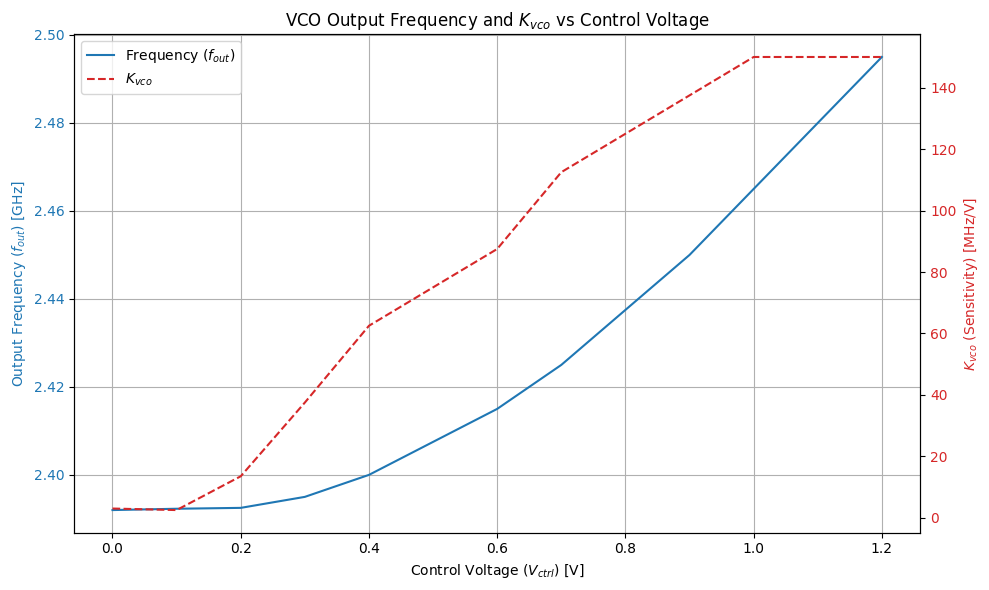

In [3]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Y-Axis
color1 = 'tab:blue'
ax1.set_xlabel('Control Voltage ($V_{ctrl}$) [V]')
ax1.set_ylabel('Output Frequency ($f_{out}$) [GHz]', color=color1)
line1 = ax1.plot(V_ctrl, freq_out, color=color1, label='Frequency ($f_{out}$)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True)

# Right Y-Axis
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('$K_{vco}$ (Sensitivity) [MHz/V]', color=color2)
line2 = ax2.plot(V_ctrl, Kvco*1e3, color=color2, linestyle='--', label='$K_{vco}$')
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Title & Layout settings
plt.title('VCO Output Frequency and $K_{vco}$ vs Control Voltage')
fig.tight_layout()

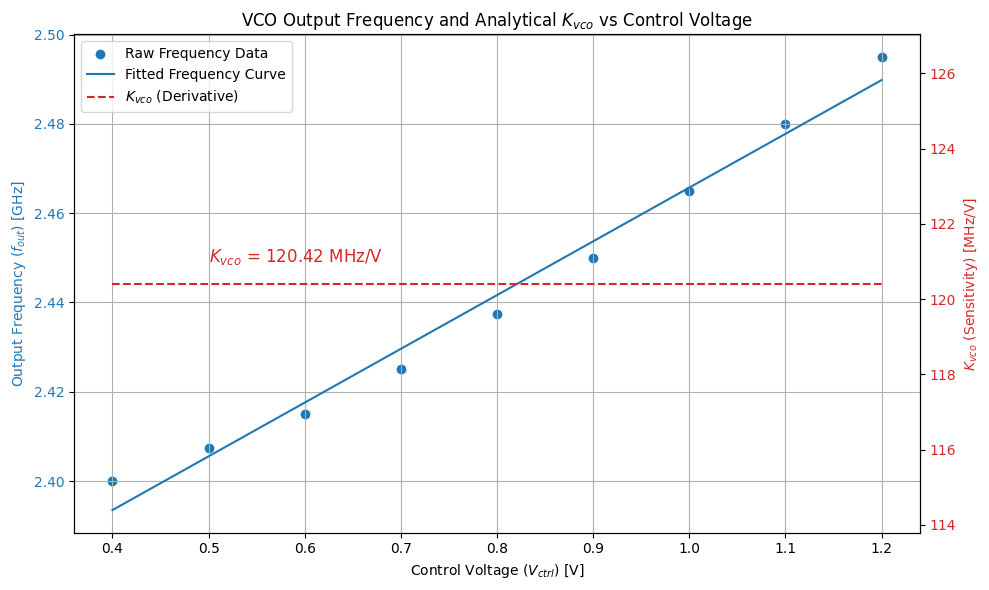

In [4]:
V_ctrl = np.array(V_ctrl[4:])
freq_out = np.array(freq_out[4:])

# Fit a polynomial curve
degree = 1
coeffs = np.polyfit(V_ctrl, freq_out, degree)
p_freq = np.poly1d(coeffs)

# Calculate the analytical derivative of the polynomial for Kvco
p_kvco = p_freq.deriv()

# Create a dense set of points for smooth plotting
V_smooth = np.linspace(V_ctrl.min(), V_ctrl.max(), 200)
freq_smooth = p_freq(V_smooth)

# Calculate Kvco and convert from GHz/V to MHz/V
Kvco_GHz_V = p_kvco(V_smooth)
Kvco_MHz_V = Kvco_GHz_V * 1000

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Control Voltage ($V_{ctrl}$) [V]')
ax1.set_ylabel('Output Frequency ($f_{out}$) [GHz]', color=color1)

# Plot raw scatter data and the smooth fitted curve
ax1.scatter(V_ctrl, freq_out, color=color1, label='Raw Frequency Data')
ax1.plot(V_smooth, freq_smooth, color=color1, linestyle='-', label='Fitted Frequency Curve')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True)

# Secondary Y-Axis for Kvco in MHz/V
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('$K_{vco}$ (Sensitivity) [MHz/V]', color=color2)
if degree == 1:
    # For linear fit, Kvco is constant and equal to the slope
    Kvco_MHz_V = np.full_like(V_smooth, coeffs[0] * 1000)  # Convert GHz/V to MHz/V
    # Add text annotation for constant Kvco
    ax2.text(0.5, 121, f'$K_{{vco}}$ = {Kvco_MHz_V[0]:.2f} MHz/V', color=color2, fontsize=12)

# Plot the derivative
ax2.plot(V_smooth, Kvco_MHz_V, color=color2, linestyle='--', label='$K_{vco}$ (Derivative)')
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('VCO Output Frequency and Analytical $K_{vco}$ vs Control Voltage')
fig.tight_layout()